# Exploratory Data Analysis — German Credit Dataset

This notebook explores the raw dataset behind the Smart Financial Data
Assistant app before any modeling decisions were made.

**Note on the target variable:** this release of the dataset (Age, Sex, Job,
Housing, Saving accounts, Checking account, Credit amount, Duration, Purpose)
does **not** include a ground-truth good/bad credit outcome. That absence is
exactly why the app uses an unsupervised K-Means segmentation model
(`src/risk_model.py`) instead of a supervised classifier trained on an
invented label — see that module's docstring for the full reasoning.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_raw_data

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = load_raw_data()
df.shape

2026-08-30 09:32:46.651 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


(1000, 10)

In [2]:
df.head()

,Age,Sex,Job,Housing,SavingAccounts,CheckingAccount,CreditAmount,Duration,Purpose,AgeGroup
0,67,male,2,own,NaN,little,1169,6,radio/TV,60+
1,22,female,2,own,little,moderate,5951,48,radio/TV,18-30
2,49,male,1,own,little,NaN,2096,12,education,46-60
3,45,male,2,free,little,little,7882,42,furniture/equipment,31-45
4,53,male,2,free,little,little,4870,24,car,46-60


## Missing values

`SavingAccounts` and `CheckingAccount` have real missing values — these mean *no such account on record*, not bad data, so they're kept as an explicit category rather than dropped or imputed.

In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
Age,0,0.0
Sex,0,0.0
Job,0,0.0
Housing,0,0.0
SavingAccounts,183,18.3
CheckingAccount,394,39.4
CreditAmount,0,0.0
Duration,0,0.0
Purpose,0,0.0
AgeGroup,0,0.0


## Numeric feature distributions

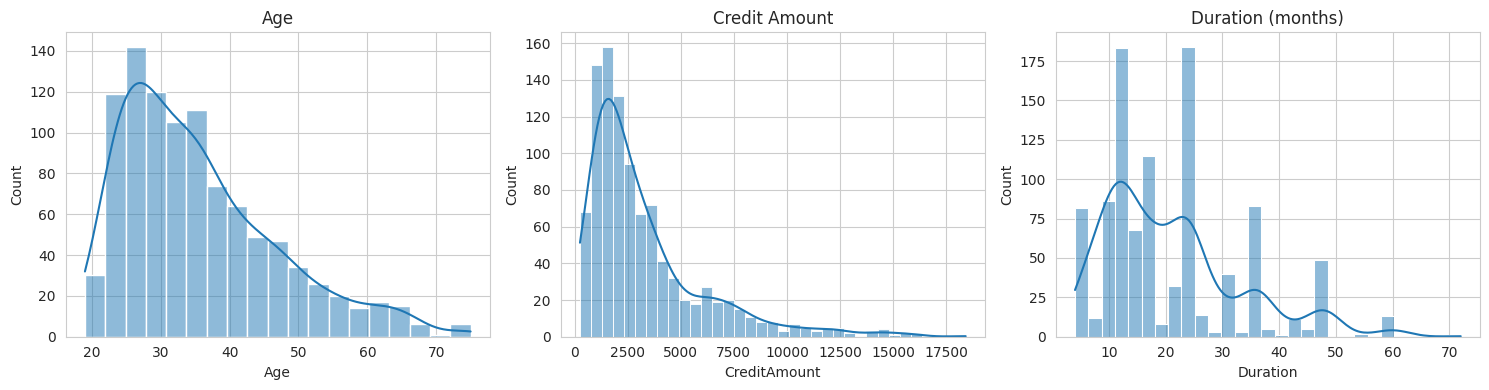

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Age"], kde=True, ax=axes[0]).set_title("Age")
sns.histplot(df["CreditAmount"], kde=True, ax=axes[1]).set_title("Credit Amount")
sns.histplot(df["Duration"], kde=True, ax=axes[2]).set_title("Duration (months)")
plt.tight_layout()
plt.show()

Credit amount and duration are both right-skewed — most loans are modest and short, with a long tail of large, long-duration loans. This tail is exactly what the risk scorecard downstream needs to be sensitive to.

## Categorical feature breakdown

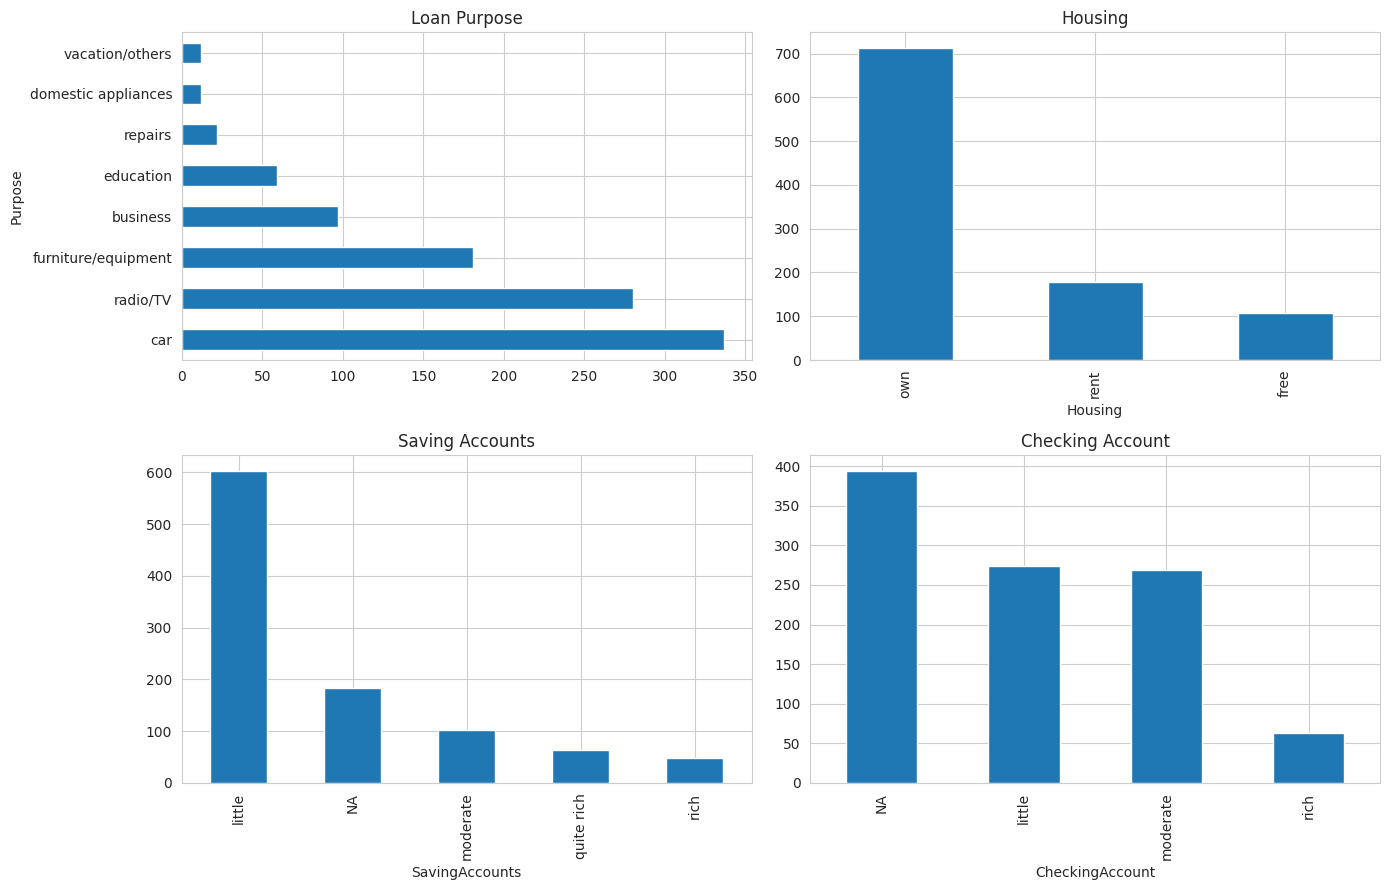

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
df["Purpose"].value_counts().plot(kind="barh", ax=axes[0,0], title="Loan Purpose")
df["Housing"].value_counts().plot(kind="bar", ax=axes[0,1], title="Housing")
df["SavingAccounts"].fillna("NA").value_counts().plot(kind="bar", ax=axes[1,0], title="Saving Accounts")
df["CheckingAccount"].fillna("NA").value_counts().plot(kind="bar", ax=axes[1,1], title="Checking Account")
plt.tight_layout()
plt.show()

## Correlations between numeric features

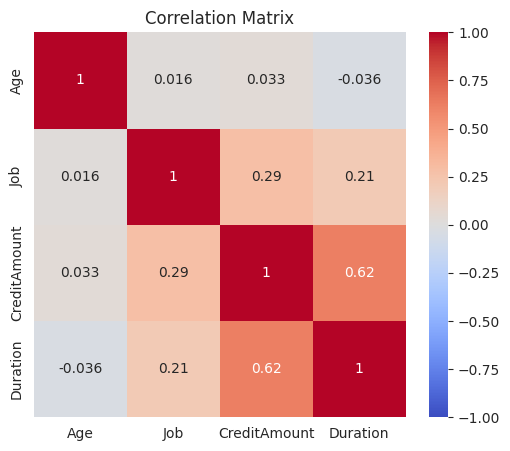

In [6]:
numeric = df.select_dtypes(include=["int64", "float64"])
corr = numeric.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

Credit amount and duration are positively correlated (larger loans tend to
run longer), which is the basis for the "installment burden" feature used
in the app's risk scorecard.


## Risk segmentation model (K-Means)

Re-running the same model the app uses, so its behavior is fully reproducible and inspectable here.

In [7]:
from src.risk_model import train_risk_model, assign_risk

artifact = train_risk_model(df)
scored = assign_risk(df)
scored["Risk"].value_counts()

Risk
Low       559
Medium    248
High      193
Name: count, dtype: int64

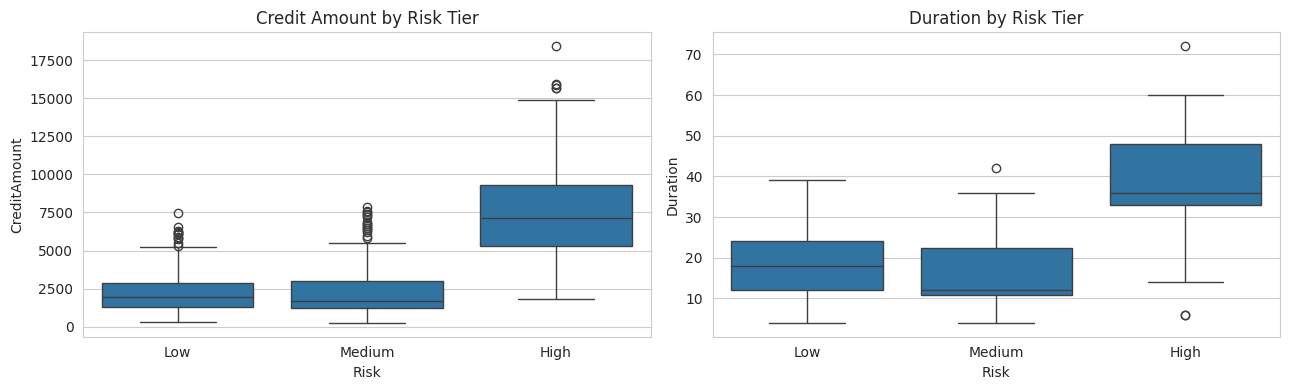

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=scored, x="Risk", y="CreditAmount", order=["Low","Medium","High"], ax=ax[0])
ax[0].set_title("Credit Amount by Risk Tier")
sns.boxplot(data=scored, x="Risk", y="Duration", order=["Low","Medium","High"], ax=ax[1])
ax[1].set_title("Duration by Risk Tier")
plt.tight_layout()
plt.show()

The tiers separate sensibly: "High" risk customers carry noticeably larger
credit amounts and longer durations than "Low" risk customers, even though
neither feature was used directly to *assign* the tier label (the tier
ranking uses cluster-level averages of both). This is a reasonable sanity
check given there's no ground-truth label to validate against directly.
